## GLOBAL FINTECH DIGITAL PAYMENTS DATASET PROJECT

## 1. Project Overview ##
In the digital payments industry, companies process millions of transactions daily across
multiple countries, currencies, payment channels, and customer segments. While the volume
of data generated is enormous, most businesses struggle to convert that data into decisions
that protect revenue, reduce risk, and improve customer experience.

This project simulates the work of a data analyst embedded in a fintech company's analytics
team. Using a realistic, messy dataset of **~100,000 payment transactions** spanning three
years across 12 countries, we will clean, analyse, and visualise the data to answer the
questions that actually matter to business stakeholders.


## 2. Dataset Overview
The Global FinTech Digital Payments Dataset is a synthetic but industry-realistic dataset modelled after real-world payment processor data,similar in structure to transaction logs from companies such as Stripe, PayPal, or African fintech providers like Flutterwave and Pesapal.

It is designed specifically for end-to-end data analytics practice, covering the full pipeline from raw messy data through cleaning, SQL analysis, exploratory data analysis, Power BI dashboarding, and stakeholder storytelling.


## 3. Dataset understanding
The dataset covers the digital payments and e-commerce financial transactions domain. The following industry contexts are represented:
•	Retail and e-commerce payment processing (online purchases across product categories)
•	Cross-border and multi-currency transactions with exchange rate data
•	Mobile and digital payment methods including mobile money, credit cards, and digital wallets
•	Fraud detection and risk management scenarios
•	Customer segmentation and lifetime value analysis


## STEPS
1. Loading the data to pandas
2. Explore and clean first
3. after cleaning save the cleaned data
4. connect to sql
5. write queries for the problems and business questions
6. visualize with matplotlib/seaborn
7. connect the csv to powerbi(or tableau) and do datamodeling, measures and dashboards
8. write a report(or ppt) with insights and recommendations

## 1. Step 1
- Loading data into pandas


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('fintech_payments_raw.csv')
df


,transaction_id,transaction_date,customer_id,customer_age,customer_segment,country,payment_method,transaction_amount_usd,currency,exchange_rate,...,merchant_name,transaction_status,is_fraud,device_type,platform,session_duration_sec,chargeback_flag,discount_applied,net_revenue_usd,customer_lifetime_value
0,F40603CD-860A-4FC8,11-09-2022,CUST012749,30,Corporate,USA,PayPal,165.45,USD,1.00000,...,Berry-Chung,Completed,0,Mobile,Android,737.8,0,0.2507,123.97,792.52
1,3130BA47-B033-4DB1,2022/02/16,CUST003490,29,CORPORATE,France,Apple Pay,2417.58,EUR,1.08000,...,"Harrington, Case and Wagner",Complete,0,Tablet,Browser,80.9,0,0.2835,1732.20,97.8
2,38D4B31F-B69D-4F24,2022-12-26,CUST000423,34,SME,France,PAYPAL,34.81,EUR,1.08000,...,"Bennett, Thompson and Peters",NaN,0,Mobile,iOS,56.3,0,0.0272,33.86,493.36
3,FE4AF4FE-1436-4B2D,2024-05-26,CUST008754,29,Basic,Kenya,bank transfer,1.06,KES,0.00750,...,Gutierrez LLC,Declined,0,Mobile,Android,622.3,0,0.2939,0.75,423.85
4,6699804A-C105-4518,2023/11/06,CUST000018,32,SME,NG,PayPal,0.03,NGN,0.00130,...,Navarro and Sons,Completed,1,Desktop,iOS,1402.3,0,0.3575,0.02,969.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101495,070C4FC3-C4B3-4FA0,2024-07-04,CUST011807,26,Corporate,Kenya,M-Pesa,6.76,KES,0.00750,...,"Kirk, Huffman and Eaton",success,0,Mobile,Android,77.6,0,0.1027,6.07,120.73
101496,54F66104-3706-4222,12-07-2023,CUST002306,35,Retail,ZA,Bank Transfer,2.53,ZAR,0.05400,...,Landry Inc,Completed,0,Desktop,USSD,61.7,0,0.1902,2.05,27775.3
101497,7EC43571-C117-42E0,2024-10-14,CUST007999,40,Retail,Nigeria,M-PESA,NaN,NGN,0.00130,...,"Meyers, Woods and Powell",Declined,0,Mobile,iOS,1047.9,0,0.0296,0.22,4834.32
101498,50A41DD8-F84A-4212,2022-11-23,CUST001786,21,Retail,Uganda,Credit Card,0.03,UGX,0.00027,...,Schultz Group,Completed,0,Desktop,Android,43.1,0,0.0486,0.03,115.69


## STEP 2
- Explore and clean

In [3]:
df = pd.read_csv('fintech_payments_raw.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101500 entries, 0 to 101499
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           101500 non-null  str    
 1   transaction_date         101500 non-null  str    
 2   customer_id              101500 non-null  str    
 3   customer_age             101500 non-null  int64  
 4   customer_segment         101500 non-null  str    
 5   country                  101500 non-null  str    
 6   payment_method           101500 non-null  str    
 7   transaction_amount_usd   98455 non-null   float64
 8   currency                 101500 non-null  str    
 9   exchange_rate            97440 non-null   float64
 10  product_category         101500 non-null  str    
 11  merchant_id              101500 non-null  str    
 12  merchant_name            101500 non-null  str    
 13  transaction_status       98766 non-null   str    
 14  is_fraud       

In [4]:
df.head()

,transaction_id,transaction_date,customer_id,customer_age,customer_segment,country,payment_method,transaction_amount_usd,currency,exchange_rate,...,merchant_name,transaction_status,is_fraud,device_type,platform,session_duration_sec,chargeback_flag,discount_applied,net_revenue_usd,customer_lifetime_value
0,F40603CD-860A-4FC8,11-09-2022,CUST012749,30,Corporate,USA,PayPal,165.45,USD,1.0000,...,Berry-Chung,Completed,0,Mobile,Android,737.8,0,0.2507,123.97,792.52
1,3130BA47-B033-4DB1,2022/02/16,CUST003490,29,CORPORATE,France,Apple Pay,2417.58,EUR,1.0800,...,"Harrington, Case and Wagner",Complete,0,Tablet,Browser,80.9,0,0.2835,1732.20,97.8
2,38D4B31F-B69D-4F24,2022-12-26,CUST000423,34,SME,France,PAYPAL,34.81,EUR,1.0800,...,"Bennett, Thompson and Peters",NaN,0,Mobile,iOS,56.3,0,0.0272,33.86,493.36
3,FE4AF4FE-1436-4B2D,2024-05-26,CUST008754,29,Basic,Kenya,bank transfer,1.06,KES,0.0075,...,Gutierrez LLC,Declined,0,Mobile,Android,622.3,0,0.2939,0.75,423.85
4,6699804A-C105-4518,2023/11/06,CUST000018,32,SME,NG,PayPal,0.03,NGN,0.0013,...,Navarro and Sons,Completed,1,Desktop,iOS,1402.3,0,0.3575,0.02,969.81


- Columns with null values ; exhange rate, transaction_amount_usd,transaction_status, session_duration,discount_applied, customer_lifetime_value

In [5]:
df.describe()

,customer_age,transaction_amount_usd,exchange_rate,is_fraud,session_duration_sec,chargeback_flag,discount_applied,net_revenue_usd
count,101500.000000,98455.000000,97440.000000,101500.000000,99470.000000,101500.000000,99978.000000,101500.000000
mean,36.257852,920.387225,0.259562,0.022729,444.002447,0.008532,0.170976,69.944739
std,36.855236,16799.617711,0.453261,0.149039,690.466589,0.091974,0.188100,350.189738
min,-5.000000,0.000000,0.000270,0.000000,-499.960340,0.000000,0.000200,0.000000
25%,26.000000,0.280000,0.001300,0.000000,115.000000,0.000000,0.071500,0.230000
50%,35.000000,2.280000,0.012000,0.000000,241.000000,0.000000,0.134300,1.870000
75%,43.000000,23.100000,0.072000,0.000000,508.200000,0.000000,0.223475,18.750000
max,999.000000,499365.251012,1.270000,1.000000,21023.600000,1.000000,2.497202,28119.600000


In [6]:
df.tail()

,transaction_id,transaction_date,customer_id,customer_age,customer_segment,country,payment_method,transaction_amount_usd,currency,exchange_rate,...,merchant_name,transaction_status,is_fraud,device_type,platform,session_duration_sec,chargeback_flag,discount_applied,net_revenue_usd,customer_lifetime_value
101495,070C4FC3-C4B3-4FA0,2024-07-04,CUST011807,26,Corporate,Kenya,M-Pesa,6.76,KES,0.00750,...,"Kirk, Huffman and Eaton",success,0,Mobile,Android,77.6,0,0.1027,6.07,120.73
101496,54F66104-3706-4222,12-07-2023,CUST002306,35,Retail,ZA,Bank Transfer,2.53,ZAR,0.05400,...,Landry Inc,Completed,0,Desktop,USSD,61.7,0,0.1902,2.05,27775.3
101497,7EC43571-C117-42E0,2024-10-14,CUST007999,40,Retail,Nigeria,M-PESA,NaN,NGN,0.00130,...,"Meyers, Woods and Powell",Declined,0,Mobile,iOS,1047.9,0,0.0296,0.22,4834.32
101498,50A41DD8-F84A-4212,2022-11-23,CUST001786,21,Retail,Uganda,Credit Card,0.03,UGX,0.00027,...,Schultz Group,Completed,0,Desktop,Android,43.1,0,0.0486,0.03,115.69
101499,A4290350-C7E5-42CB,05/04/2024,CUST007353,44,Corporate,United States,Airtel Money,138.42,USD,1.00000,...,"Jensen, Arnold and Smith",Complete,0,Tablet,iOS,375.9,0,0.2548,103.15,363.78


## DATA CLEANING
- Data quality issues
- The following categories of messiness are embedded across the dataset:
•	Duplicates: Repeated transaction_id values (~1.5% of rows)
•	Missing values: Nulls in transaction_amount_usd, exchange_rate, transaction_status, and customer_lifetime_value
•	Outliers: Extreme values in customer_age (e.g. 999, -5), transaction_amount_usd, session_duration_sec, and discount_applied (>100%)
•	Inconsistent categories: Mixed casing and spelling variants in customer_segment, platform, payment_method, product_category, and country
•	Date format inconsistency: transaction_date stored in multiple formats across rows


In [7]:
#Dropping duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

0

In [9]:
#Missing values/Null values
df.isnull().sum()


transaction_id                0
transaction_date              0
customer_id                   0
customer_age                  0
customer_segment              0
country                       0
payment_method                0
transaction_amount_usd     3045
currency                      0
exchange_rate              4058
product_category              0
merchant_id                   0
merchant_name                 0
transaction_status         2733
is_fraud                      0
device_type                   0
platform                      0
session_duration_sec       2030
chargeback_flag               0
discount_applied           1521
net_revenue_usd               0
customer_lifetime_value    5581
dtype: int64

In [10]:
#TRANSACTION AMOUNT COLUMN
df['transaction_amount_usd'].describe()

count     97565.000000
mean        928.036986
std       16875.830564
min           0.000000
25%           0.280000
50%           2.280000
75%          23.110000
max      499365.251012
Name: transaction_amount_usd, dtype: float64

In [11]:
df['transaction_amount_usd'] = df['transaction_amount_usd'].fillna(df['transaction_amount_usd'].median())

In [12]:
df['transaction_amount_usd'].isnull().sum()

0

In [13]:
df['session_duration_sec'].isnull().sum()

2030

In [14]:
##check for negative session durations
(df['session_duration_sec']<0).sum()

587

In [15]:
#fill the negative session durations with nan then with median
df.loc[df['session_duration_sec']<0,'session_duration_sec'] = np.nan
df['session_duration_sec'] = df['session_duration_sec'].fillna(df['session_duration_sec'].median())
(df['session_duration_sec']<0).sum()


0

In [16]:
#OUTLIERS IN THE AGE COLUMN
((df['customer_age']<18 )| (df['customer_age']>100)).sum()

500

In [17]:
#FILL THOSE COLUMNS WITH NAN THEN IMPUTE WITH MEDIAN AGE
df.loc[(df['customer_age']<18 )| (df['customer_age']>100),'customer_age'] = np.nan
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())


In [18]:
df['customer_age'].isnull().sum()

0

In [19]:
#STANDARDIZING DATES
df['transaction_date'].head(10)

0     11-09-2022
1     2022/02/16
2     2022-12-26
3     2024-05-26
4     2023/11/06
5     2024-02-18
6    13-Sep-2022
7     2023-03-03
8     2023/12/10
9     27/11/2023
Name: transaction_date, dtype: str

In [20]:
# Convert using the flexible parser
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_date'].head(10)

0   2022-11-09
1   2022-02-16
2   2022-12-26
3   2024-05-26
4   2023-11-06
5   2024-02-18
6   2022-09-13
7   2023-03-03
8   2023-12-10
9   2023-11-27
Name: transaction_date, dtype: datetime64[us]

In [21]:
df['transaction_date'].isna().sum()

0

In [22]:
#TRANSACTION AMOUNT OUTLIERS AND NULLS
q1  = df['transaction_amount_usd'].quantile(0.25)
q3  = df['transaction_amount_usd'].quantile(0.75)
iqr = q3 - q1
upper_cap = q3 + 3 * iqr
iqr

df['transaction_amount_usd'] = df['transaction_amount_usd'].clip(upper_cap)
df['transaction_amount_usd'] = df['transaction_amount_usd'].fillna(df['transaction_amount_usd'].median())
df['transaction_amount_usd'].describe()

count    100610.000000
mean        964.681729
std       16615.790011
min          83.660000
25%          83.660000
50%          83.660000
75%          83.660000
max      499365.251012
Name: transaction_amount_usd, dtype: float64

In [23]:
#FIX DISCOUNT VALUES ABOVE 1 OR BELOW 0. (MEANING THEY ARE ABOVE 100% OR IN THE NEGATIVE)
extreme_disc = (df['discount_applied']>0).sum()
extreme_disc

99089

In [24]:
df['discount_applied'] = df['discount_applied'].clip(0, 1)
df['discount_applied'].fillna(df['discount_applied'].median())

0         0.2507
1         0.2835
2         0.0272
3         0.2939
4         0.3575
           ...  
101494    0.2746
101495    0.1027
101496    0.1902
101497    0.0296
101498    0.0486
Name: discount_applied, Length: 100610, dtype: float64

In [25]:
#MISSING EXCHANGE RATES (IMPUTING)
missing_rates = df['exchange_rate'].isnull().sum()
missing_rates

4058

In [26]:
df['exchange_rate'] = df.groupby('currency')['exchange_rate'].transform(lambda x : x.fillna(x.median()))


In [27]:
#STANDARDIZING FOUR COLUMNS IN ONE FUNCTION AND MAPPING (PAYMENT METHOD, CUSTOMER SEGMENT, COUNTRY,PLATFORM)
# 1. Automated Cleaning (Fixes casing, dashes, and extra spaces)
def auto_standardise(series):
    return (series
            .str.strip()
            .str.lower()
            .str.replace(r'[-_]', ' ', regex=True) # Turn 'm-pesa' into 'm pesa'
            .str.title()) # Turn 'm pesa' into 'M Pesa'

# 2. Minimalist Correction Map (Only for things logic can't fix)
special_cases = {
    'M Pesa': 'M-Pesa',
    'mpesa':'M-pesa',
    'Mpesa':'M-pesa',
    'Cc': 'Credit Card',
    'Dc': 'Debit Card',
    'Sme': 'SME',
    'Usa': 'United States',
    'Uk': 'United Kingdom'
}

# 3. Apply to the four columns
category_cols = ['payment_method', 'customer_segment', 'country', 'platform']

for col in category_cols:
    # First, run the automated logic
    df[col] = auto_standardise(df[col])
    # Then, only map the special cases
    df[col] = df[col].replace(special_cases)
    
    
    

In [28]:
df['payment_method'].head(10)

0           Paypal
1        Apple Pay
2           Paypal
3    Bank Transfer
4           Paypal
5        Apple Pay
6           M-Pesa
7       Debit Card
8           M-Pesa
9    Crypto Wallet
Name: payment_method, dtype: str

In [29]:
df.head(20)

,transaction_id,transaction_date,customer_id,customer_age,customer_segment,country,payment_method,transaction_amount_usd,currency,exchange_rate,...,merchant_name,transaction_status,is_fraud,device_type,platform,session_duration_sec,chargeback_flag,discount_applied,net_revenue_usd,customer_lifetime_value
0,F40603CD-860A-4FC8,2022-11-09,CUST012749,30.0,Corporate,United States,Paypal,165.450000,USD,1.0000,...,Berry-Chung,Completed,0,Mobile,Android,737.8,0,0.2507,123.97,792.52
1,3130BA47-B033-4DB1,2022-02-16,CUST003490,29.0,Corporate,France,Apple Pay,2417.580000,EUR,1.0800,...,"Harrington, Case and Wagner",Complete,0,Tablet,Browser,80.9,0,0.2835,1732.20,97.8
2,38D4B31F-B69D-4F24,2022-12-26,CUST000423,34.0,SME,France,Paypal,83.660000,EUR,1.0800,...,"Bennett, Thompson and Peters",NaN,0,Mobile,Ios,56.3,0,0.0272,33.86,493.36
3,FE4AF4FE-1436-4B2D,2024-05-26,CUST008754,29.0,Basic,Kenya,Bank Transfer,83.660000,KES,0.0075,...,Gutierrez LLC,Declined,0,Mobile,Android,622.3,0,0.2939,0.75,423.85
4,6699804A-C105-4518,2023-11-06,CUST000018,32.0,SME,Ng,Paypal,83.660000,NGN,0.0013,...,Navarro and Sons,Completed,1,Desktop,Ios,1402.3,0,0.3575,0.02,969.81
5,D8CBA630-CCE9-45E0,2024-02-18,CUST013384,49.0,Small Business,Nigeria,Apple Pay,83.660000,NGN,0.0013,...,"Franklin, Mills and Davis",Pending,0,Mobile,Point Of Sale,355.6,0,0.1889,1.67,2026.5
6,AD9392AE-AB5F-4B27,2022-09-13,CUST004139,34.0,Retail,Tanzania,M-Pesa,83.660000,TZS,0.0004,...,"Daugherty, Clark and Haynes",completed,0,Mobile,Web,361.9,0,0.1512,0.23,1938.3
7,9A369796-6C31-4644,2023-03-03,CUST011350,45.0,Corporate,Ghana,Debit Card,83.660000,GHS,0.0720,...,Paul-Nash,Complete,0,Desktop,Android,23.0,0,0.1285,1.59,NaN
8,B0FE7FAC-9B7A-4722,2023-12-10,CUST002354,37.0,SME,Ghana,M-Pesa,83.660000,GHS,0.0720,...,Mcclure and Sons,Completed,0,Desktop,Android,50.1,0,0.1365,5.55,129.13
9,2AC9649C-AE5B-492A,2023-11-27,CUST012667,27.0,SME,Nigeria,Crypto Wallet,83.660000,NGN,0.0013,...,Hogan-Cooper,Failed,0,Desktop,Android,51.7,0,0.0234,0.05,783.75


In [30]:
df['transaction_status'].value_counts()

transaction_status
Completed      58018
Failed          6280
Pending         5576
Declined        4784
SUCCESS         3759
success         3695
Complete        3668
completed       3554
Refunded        3316
Failure          507
failed           479
FAILED           476
PENDING          437
pending          431
In Progress      418
declined         369
DECLINED         355
Rejected         343
refunded         317
REFUNDED         312
?                123
check later      123
ok               117
error            111
not sure         106
TBD              105
done              98
Name: count, dtype: int64

In [31]:
#STANDARDIZE TRANSACTION STATUS
# 1. First, fix casing and spacing (Handles: SUCCESS, success, completed,  Pending )
df['transaction_status'] = auto_standardise(df['transaction_status'])

# 2. Map synonyms to canonical values
# This collapses different words that mean the same thing
status_synonyms = {
    'Success': 'Completed',
    'Complete': 'Completed',
    'Done': 'Completed',
    'Ok': 'Completed',
    'Failure': 'Failed',
    'Error': 'Failed',
    'In Progress': 'Pending',
    'Check Later': 'Pending',
    'Tbd': 'Pending',
    'Rejected': 'Declined'
}
df['transaction_status'] = df['transaction_status'].replace(status_synonyms)

# 3. Removing 'ok','tbd''etc' 
valid_statuses = ['Completed', 'Failed', 'Pending', 'Declined', 'Refunded']

df['transaction_status'] = df['transaction_status'].where(
    df['transaction_status'].isin(valid_statuses), 'Unknown'
)

# 4. Final safety fill for NaNs
df['transaction_status'] = df['transaction_status'].fillna('Unknown')

print(df['transaction_status'].value_counts())

transaction_status
Completed    72909
Failed        7853
Pending       7090
Declined      5851
Refunded      3945
Unknown       2962
Name: count, dtype: int64


In [32]:
# #INCONSISTENT CATEGORIES
#  #Consolidate into a single configuration
# mapping_config = {
#     'payment_method': payment_map,
#     'customer_segment': segment_map,
#     'platform': platform_map,
#     'product_category': category_map,
#     'country': country_map,
#     'transaction_status': status_map
# }

# #Using a loop to apply normalization to all columns
# for col, cmap in mapping_config.items():
#     if col in df.columns:
#         df[col] = df[col].str.strip().str.lower().map(cmap).fillna(df[col].str.strip())

In [33]:
#STANDARDIZE CUSTOMER LIFETIME VALUE COLUMN
# 1. Clean symbols and convert to numeric in one chain
df['customer_lifetime_value'] = (
    df['customer_lifetime_value']
    .replace(r'[\$,]', '', regex=True)  
    .pipe(pd.to_numeric, errors='coerce')
)

# 2. Impute missing values with the median
df['customer_lifetime_value'] = df['customer_lifetime_value'].fillna(df['customer_lifetime_value'].median())
df['customer_lifetime_value'].dtype


dtype('float64')

In [34]:
df.head(10)

,transaction_id,transaction_date,customer_id,customer_age,customer_segment,country,payment_method,transaction_amount_usd,currency,exchange_rate,...,merchant_name,transaction_status,is_fraud,device_type,platform,session_duration_sec,chargeback_flag,discount_applied,net_revenue_usd,customer_lifetime_value
0,F40603CD-860A-4FC8,2022-11-09,CUST012749,30.0,Corporate,United States,Paypal,165.45,USD,1.0000,...,Berry-Chung,Completed,0,Mobile,Android,737.8,0,0.2507,123.97,792.52
1,3130BA47-B033-4DB1,2022-02-16,CUST003490,29.0,Corporate,France,Apple Pay,2417.58,EUR,1.0800,...,"Harrington, Case and Wagner",Completed,0,Tablet,Browser,80.9,0,0.2835,1732.20,97.80
2,38D4B31F-B69D-4F24,2022-12-26,CUST000423,34.0,SME,France,Paypal,83.66,EUR,1.0800,...,"Bennett, Thompson and Peters",Unknown,0,Mobile,Ios,56.3,0,0.0272,33.86,493.36
3,FE4AF4FE-1436-4B2D,2024-05-26,CUST008754,29.0,Basic,Kenya,Bank Transfer,83.66,KES,0.0075,...,Gutierrez LLC,Declined,0,Mobile,Android,622.3,0,0.2939,0.75,423.85
4,6699804A-C105-4518,2023-11-06,CUST000018,32.0,SME,Ng,Paypal,83.66,NGN,0.0013,...,Navarro and Sons,Completed,1,Desktop,Ios,1402.3,0,0.3575,0.02,969.81
5,D8CBA630-CCE9-45E0,2024-02-18,CUST013384,49.0,Small Business,Nigeria,Apple Pay,83.66,NGN,0.0013,...,"Franklin, Mills and Davis",Pending,0,Mobile,Point Of Sale,355.6,0,0.1889,1.67,2026.50
6,AD9392AE-AB5F-4B27,2022-09-13,CUST004139,34.0,Retail,Tanzania,M-Pesa,83.66,TZS,0.0004,...,"Daugherty, Clark and Haynes",Completed,0,Mobile,Web,361.9,0,0.1512,0.23,1938.30
7,9A369796-6C31-4644,2023-03-03,CUST011350,45.0,Corporate,Ghana,Debit Card,83.66,GHS,0.0720,...,Paul-Nash,Completed,0,Desktop,Android,23.0,0,0.1285,1.59,667.48
8,B0FE7FAC-9B7A-4722,2023-12-10,CUST002354,37.0,SME,Ghana,M-Pesa,83.66,GHS,0.0720,...,Mcclure and Sons,Completed,0,Desktop,Android,50.1,0,0.1365,5.55,129.13
9,2AC9649C-AE5B-492A,2023-11-27,CUST012667,27.0,SME,Nigeria,Crypto Wallet,83.66,NGN,0.0013,...,Hogan-Cooper,Failed,0,Desktop,Android,51.7,0,0.0234,0.05,783.75


In [35]:
df['country'].value_counts()

country
Kenya             15863
Nigeria           14138
South Africa      10074
United States      8234
Ghana              6957
United Kingdom     6480
Egypt              6247
Tanzania           5306
India              5239
Uganda             4287
Germany            2694
France             2674
Ke                 2251
Ng                 2077
Za                 1082
Sa                 1005
Gh                  990
Eg                  834
In                  813
Tz                  764
Us                  754
Ug                  607
Gb                  549
Fr                  354
De                  337
Name: count, dtype: int64

In [36]:
#STANDARDIZE THE COUNTRY COLUMNS
# Creating a mapping of the codes to full country names
country_map = {
    'Ke': 'Kenya',
    'Ng': 'Nigeria',
    'Za': 'South Africa',
    'Us': 'United States',
    'Gh': 'Ghana',
    'Gb': 'United Kingdom',
    'Eg': 'Egypt',
    'Tz': 'Tanzania',
    'In': 'India',
    'Ug': 'Uganda',
    'De': 'Germany',
    'Fr': 'France',
    'Sa': 'South Africa'
}

# Apply the mapping
df['country'] = df['country'].replace(country_map)

# Verify the fix
print(df['country'].value_counts())

country
Kenya             18114
Nigeria           16215
South Africa      12161
United States      8988
Ghana              7947
Egypt              7081
United Kingdom     7029
Tanzania           6070
India              6052
Uganda             4894
Germany            3031
France             3028
Name: count, dtype: int64


In [37]:
#RECALCULATE NET_REVENUE_USD AFTER CLEANING
df['net_revenue_usd'] = (df['transaction_amount_usd'] * (1 - df['discount_applied'])).round(2)
df['net_revenue_usd'].head()

0     123.97
1    1732.20
2      81.38
3      59.07
4      53.75
Name: net_revenue_usd, dtype: float64

In [38]:
df['discount_applied'] = df['discount_applied'].fillna(0)
df['discount_applied'].isnull().sum()


0

In [39]:
#RECALCULATE NET_REVENUE_USD AFTER CLEANING
df['net_revenue_usd'] = (df['transaction_amount_usd'] * (1 - df['discount_applied'])).round(2)
df['net_revenue_usd'].head()

0     123.97
1    1732.20
2      81.38
3      59.07
4      53.75
Name: net_revenue_usd, dtype: float64

In [40]:
remaining_nulls = df.isnull().sum()
remaining_nulls


transaction_id             0
transaction_date           0
customer_id                0
customer_age               0
customer_segment           0
country                    0
payment_method             0
transaction_amount_usd     0
currency                   0
exchange_rate              0
product_category           0
merchant_id                0
merchant_name              0
transaction_status         0
is_fraud                   0
device_type                0
platform                   0
session_duration_sec       0
chargeback_flag            0
discount_applied           0
net_revenue_usd            0
customer_lifetime_value    0
dtype: int64

## DONE WITH DATA CLEANING
- NEXT LOAD THE CLEANED DATA THEN CONNECT TO SQLITE3

In [41]:
# Save cleaned CSV
df.to_csv('fintech_payments_clean.csv', index=False)
print("Cleaned dataset saved → fintech_payments_clean.csv")

# Load into SQLite
conn = sqlite3.connect('fintech.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)
print("Loaded into SQLite table 'transactions'")

Cleaned dataset saved → fintech_payments_clean.csv
Loaded into SQLite table 'transactions'


### Business Questions

In [42]:
df=pd.read_sql("SELECT * FROM transactions",conn)
df

,transaction_id,transaction_date,customer_id,customer_age,customer_segment,country,payment_method,transaction_amount_usd,currency,exchange_rate,...,merchant_name,transaction_status,is_fraud,device_type,platform,session_duration_sec,chargeback_flag,discount_applied,net_revenue_usd,customer_lifetime_value
0,F40603CD-860A-4FC8,2022-11-09 00:00:00,CUST012749,30.0,Corporate,United States,Paypal,165.45,USD,1.00000,...,Berry-Chung,Completed,0,Mobile,Android,737.8,0,0.2507,123.97,792.52
1,3130BA47-B033-4DB1,2022-02-16 00:00:00,CUST003490,29.0,Corporate,France,Apple Pay,2417.58,EUR,1.08000,...,"Harrington, Case and Wagner",Completed,0,Tablet,Browser,80.9,0,0.2835,1732.20,97.80
2,38D4B31F-B69D-4F24,2022-12-26 00:00:00,CUST000423,34.0,SME,France,Paypal,83.66,EUR,1.08000,...,"Bennett, Thompson and Peters",Unknown,0,Mobile,Ios,56.3,0,0.0272,81.38,493.36
3,FE4AF4FE-1436-4B2D,2024-05-26 00:00:00,CUST008754,29.0,Basic,Kenya,Bank Transfer,83.66,KES,0.00750,...,Gutierrez LLC,Declined,0,Mobile,Android,622.3,0,0.2939,59.07,423.85
4,6699804A-C105-4518,2023-11-06 00:00:00,CUST000018,32.0,SME,Nigeria,Paypal,83.66,NGN,0.00130,...,Navarro and Sons,Completed,1,Desktop,Ios,1402.3,0,0.3575,53.75,969.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100605,E0D3C568-A229-4A2B,2024-03-01 00:00:00,CUST000973,48.0,Corporate,France,Google Pay,3149.98,EUR,1.08000,...,Cobb-Trujillo,Completed,0,Mobile,Pos Terminal,671.1,0,0.2746,2285.00,1823.97
100606,070C4FC3-C4B3-4FA0,2024-07-04 00:00:00,CUST011807,26.0,Corporate,Kenya,M-Pesa,83.66,KES,0.00750,...,"Kirk, Huffman and Eaton",Completed,0,Mobile,Android,77.6,0,0.1027,75.07,120.73
100607,54F66104-3706-4222,2023-12-07 00:00:00,CUST002306,35.0,Retail,South Africa,Bank Transfer,83.66,ZAR,0.05400,...,Landry Inc,Completed,0,Desktop,Ussd,61.7,0,0.1902,67.75,27775.30
100608,7EC43571-C117-42E0,2024-10-14 00:00:00,CUST007999,40.0,Retail,Nigeria,M-Pesa,83.66,NGN,0.00130,...,"Meyers, Woods and Powell",Declined,0,Mobile,Ios,1047.9,0,0.0296,81.18,4834.32


#### Which countries or regions contribute the most revenue, and which are underperforming?

In [43]:
df_high_country_revenue=pd.read_sql("""
SELECT country, SUM(net_revenue_usd) AS Total_Revenue
                            FROM transactions
                            GROUP BY country
                            ORDER BY Total_Revenue DESC
""",conn)
df_high_country_revenue.head(10)

,country,Total_Revenue
0,Kenya,14145800.49
1,Nigeria,11937341.53
2,South Africa,9856828.69
3,United Kingdom,7795986.03
4,United States,6392837.58
5,Egypt,5743883.15
6,Uganda,5514177.17
7,Tanzania,5071992.05
8,Ghana,4993789.73
9,Germany,4374263.09


visualization of high performing countries

/tmp/ipykernel_66337/708514304.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Country')

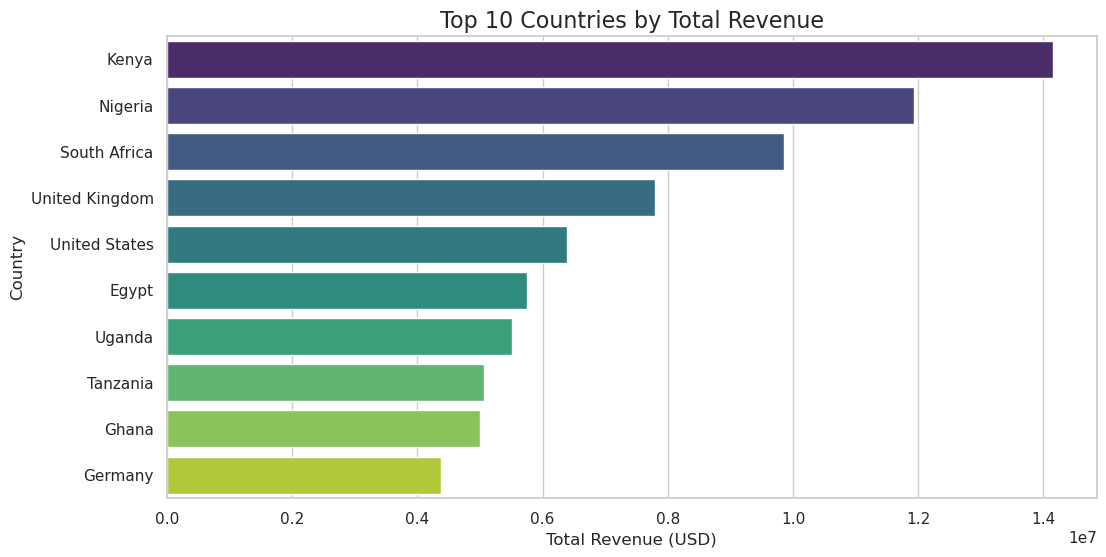

In [44]:
# Set the visual style
sns.set_theme(style="whitegrid")

# 1. Select the top 10 countries
top_10_countries = df_high_country_revenue.head(10)

# 2. Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_countries, 
    x='Total_Revenue', 
    y='country', 
    palette='viridis'
)

# 3. Add labels and title
plt.title('Top 10 Countries by Total Revenue', fontsize=16)
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('Country', fontsize=12)

Underperfoming countries

In [45]:
df_high_country_revenue.tail(10)

,country,Total_Revenue
2,South Africa,9856828.69
3,United Kingdom,7795986.03
4,United States,6392837.58
5,Egypt,5743883.15
6,Uganda,5514177.17
7,Tanzania,5071992.05
8,Ghana,4993789.73
9,Germany,4374263.09
10,India,3466885.10
11,France,2091208.50


Visualisation for underperforming countries

/tmp/ipykernel_66337/826833585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


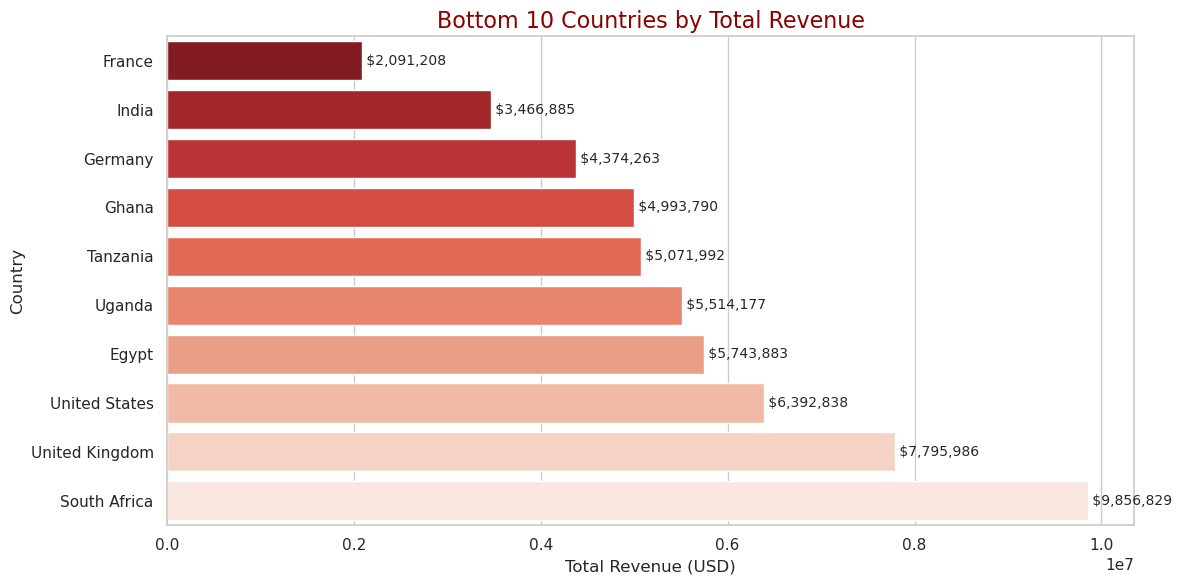

In [46]:

# 1. Get the last 10 rows and sort so the lowest is at the top of the plot
bottom_10_countries = df_high_country_revenue.tail(10).sort_values('Total_Revenue', ascending=True)

# 2. Create a Horizontal Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=bottom_10_countries, 
    x='Total_Revenue', 
    y='country', 
    palette='Reds_r' # Red palette highlights the "danger" or "low" values
)

# 3. Formatting
plt.title('Bottom 10 Countries by Total Revenue', fontsize=16, color='darkred')
plt.xlabel('Total Revenue (USD)', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Optional: Add currency labels to the bars
for i, value in enumerate(bottom_10_countries['Total_Revenue']):
    plt.text(value, i, f' ${value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Which product categories generate the highest net revenue vs. highest volume — are they the same?
High revenue products

In [47]:
df_high_revenue_products=pd.read_sql("""
SELECT 
    product_category,
    SUM(net_revenue_usd) AS total_revenue,
    COUNT(transaction_id) AS total_volume,
    SUM(net_revenue_usd) / COUNT(transaction_id) AS avg_transaction_value
FROM transactions
GROUP BY product_category
ORDER BY total_revenue DESC
""",conn)
df_high_revenue_products.head(10)

,product_category,total_revenue,total_volume,avg_transaction_value
0,Groceries,7959926.81,7857,1013.100014
1,Travel & Hospitality,7951722.71,7861,1011.540861
2,Home & Furniture,6862528.30,7746,885.944784
3,Electronics,6525960.08,8032,812.495030
4,Health & Beauty,6462486.68,7863,821.885626
5,Financial Services,6014979.70,7774,773.730345
6,Automotive,5886260.60,8117,725.176863
7,Entertainment,5516114.13,8029,687.023805
8,Education,4958779.07,8106,611.741805
9,Fashion & Apparel,4449588.02,7758,573.548340


visualization for high revenue products

/tmp/ipykernel_66337/3912222953.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_products,


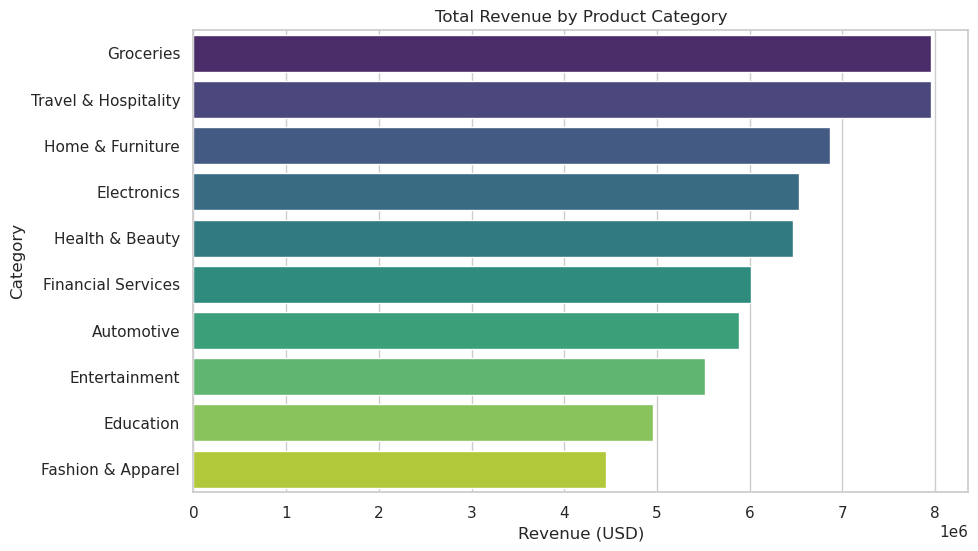

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# We sort by total_revenue to make the ranking clear
top_10_products = df_high_revenue_products.head(10)
sns.barplot(data=top_10_products, 
            x='total_revenue', 
            y='product_category', 
            palette='viridis')

plt.title('Total Revenue by Product Category')
plt.xlabel('Revenue (USD)')
plt.ylabel('Category')
plt.show()

####  Underperfoming products

In [49]:
df_high_revenue_products.tail(10)

,product_category,total_revenue,total_volume,avg_transaction_value
26,financial services,552238.93,765,721.880954
27,Finance,532983.71,788,676.375266
28,Auto,505979.39,1032,490.290107
29,Travel,478000.95,818,584.353240
30,groceries,342134.10,751,455.571372
31,Hospitality,321447.63,702,457.902607
32,education,302738.20,924,327.638745
33,Media & Entertainment,249000.87,949,262.382371
34,travel,191202.05,780,245.130833
35,Clothing,183831.10,762,241.248163


Visualization for Underperforming products

/tmp/ipykernel_66337/1369464273.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_products,


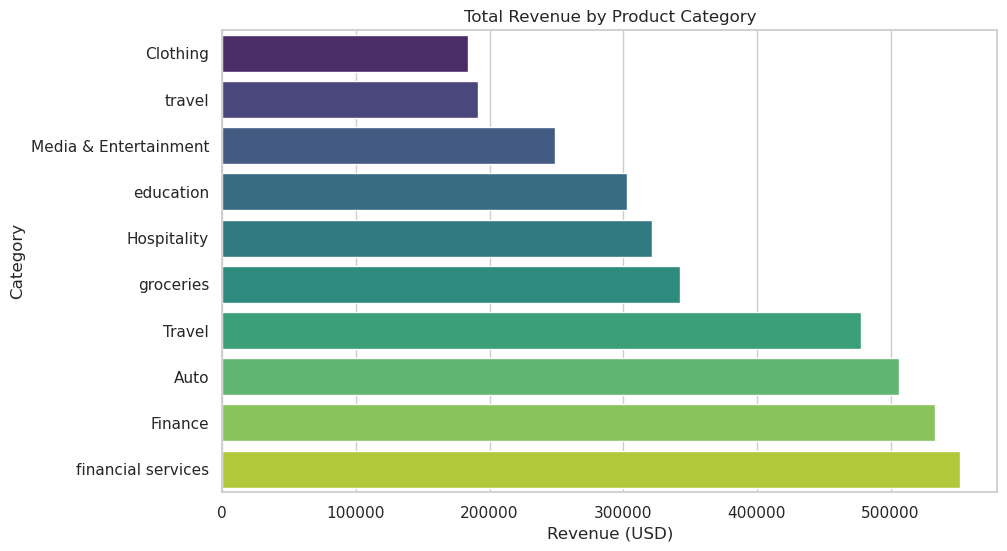

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# We sort by total_revenue to make the ranking clear
top_10_products = df_high_revenue_products.tail(10).sort_values('total_revenue', ascending=True)
sns.barplot(data=top_10_products, 
            x='total_revenue', 
            y='product_category', 
            palette='viridis')

plt.title('Total Revenue by Product Category')
plt.xlabel('Revenue (USD)')
plt.ylabel('Category')
plt.show()

MoM&YoY returns

In [51]:
df_returns = pd.read_sql("""
SELECT 
    curr.month_date AS transaction_date,
    curr.monthly_revenue AS current_revenue,
    
    -- Month-over-Month
    mom.monthly_revenue AS prev_month_revenue,
    ((curr.monthly_revenue - mom.monthly_revenue) / CAST(NULLIF(mom.monthly_revenue, 0) AS FLOAT)) * 100 AS mom_growth_pct,
    
    -- Year-over-Year
    yoy.monthly_revenue AS prev_year_revenue,
    ((curr.monthly_revenue - yoy.monthly_revenue) / CAST(NULLIF(yoy.monthly_revenue, 0) AS FLOAT)) * 100 AS yoy_growth_pct

FROM (
    -- Subquery A: Totals per month
    SELECT date(transaction_date, 'start of month') as month_date, SUM(net_revenue_usd) as monthly_revenue
    FROM transactions GROUP BY 1
) curr
LEFT JOIN (
    -- Subquery B: Same totals for MoM join
    SELECT date(transaction_date, 'start of month') as month_date, SUM(net_revenue_usd) as monthly_revenue
    FROM transactions GROUP BY 1
) mom ON mom.month_date = date(curr.month_date, '-1 month')
LEFT JOIN (
    -- Subquery C: Same totals for YoY join
    SELECT date(transaction_date, 'start of month') as month_date, SUM(net_revenue_usd) as monthly_revenue
    FROM transactions GROUP BY 1
) yoy ON yoy.month_date = date(curr.month_date, '-1 year')

ORDER BY curr.month_date DESC;
""", conn)
df_returns.head(10)

,transaction_date,current_revenue,prev_month_revenue,mom_growth_pct,prev_year_revenue,yoy_growth_pct
0,2024-12-01,3198621.35,2179488.57,46.760180,3299807.21,-3.066417
1,2024-11-01,2179488.57,2764077.15,-21.149503,2548746.76,-14.487834
2,2024-10-01,2764077.15,1471550.88,87.834290,3970287.25,-30.380928
3,2024-09-01,1471550.88,3263679.88,-54.911298,2672016.04,-44.927319
4,2024-08-01,3263679.88,2977345.48,9.617104,3366867.04,-3.064783
5,2024-07-01,2977345.48,2445538.63,21.746001,2580775.78,15.366298
6,2024-06-01,2445538.63,1971264.30,24.059398,1630929.49,49.947539
7,2024-05-01,1971264.30,2253860.30,-12.538310,3178980.52,-37.990677
8,2024-04-01,2253860.30,1600878.97,40.788925,764786.78,194.704401
9,2024-03-01,1600878.97,1294894.32,23.630087,1824252.64,-12.244667


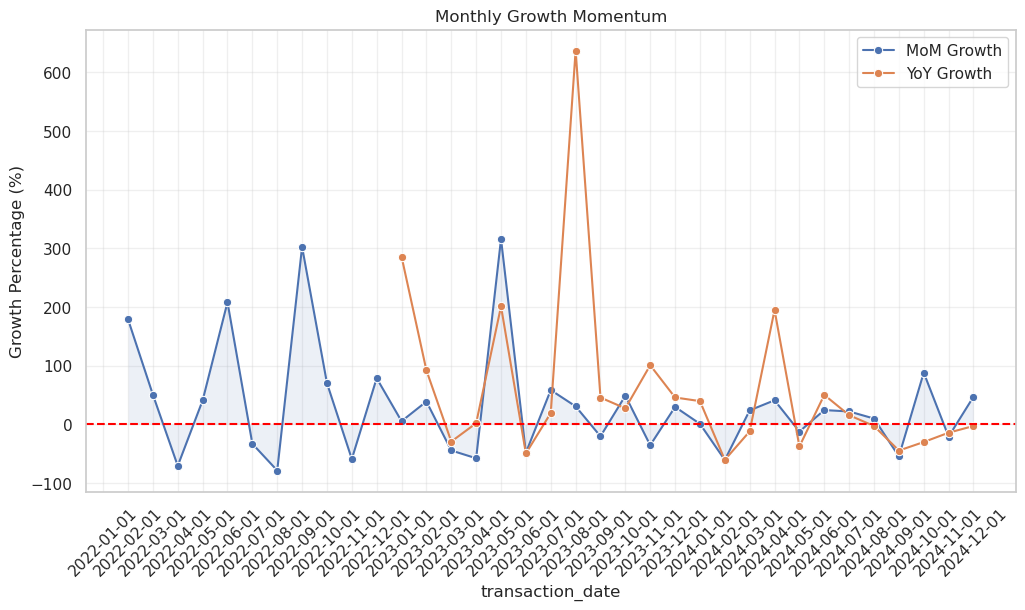

In [52]:
plt.figure(figsize=(12, 6))
df_plot = df_returns.sort_values('transaction_date')
sns.lineplot(data=df_plot, x='transaction_date', y='mom_growth_pct', label='MoM Growth', marker='o')
sns.lineplot(data=df_plot, x='transaction_date', y='yoy_growth_pct', label='YoY Growth', marker='o')

plt.axhline(0, color='red', linestyle='--') # The "Break-even" growth line
plt.fill_between(df_plot['transaction_date'], df_plot['mom_growth_pct'], alpha=0.1)

plt.title('Monthly Growth Momentum')
plt.ylabel('Growth Percentage (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

#### What is the average transaction value by payment method, and how does it vary by customer segment?

In [53]:
df_avg_transaction_value=pd.read_sql("""
SELECT 
    -- 1. Standardize the names (Merging crypto/cryptocurrency and cleaning spaces)
    CASE 
        WHEN LOWER(REPLACE(payment_method, ' ', '')) IN ('crypto', 'cryptocurrency') THEN 'crypto'
        ELSE LOWER(REPLACE(payment_method, ' ', '')) 
    END AS clean_payment_method,

    -- 2. Pivot the segments into columns using CASE WHEN
    ROUND(AVG(CASE WHEN customer_segment = 'Corporate' THEN transaction_amount_usd END), 2) AS Corporate,
    ROUND(AVG(CASE WHEN customer_segment = 'SME' THEN transaction_amount_usd END), 2) AS SME,
    ROUND(AVG(CASE WHEN customer_segment = 'Retail' THEN transaction_amount_usd END), 2) AS Retail,
    ROUND(AVG(CASE WHEN customer_segment = 'Premium' THEN transaction_amount_usd END), 2) AS Premium,
    ROUND(AVG(CASE WHEN customer_segment = 'Standard' THEN transaction_amount_usd END), 2) AS Standard,
    ROUND(AVG(CASE WHEN customer_segment = 'Basic' THEN transaction_amount_usd END), 2) AS Basic,
    
    -- 3. Calculate an overall average for the method
    ROUND(AVG(transaction_amount_usd), 2) AS method_overall_avg

FROM transactions
GROUP BY 1  -- Group by the cleaned payment method name
ORDER BY method_overall_avg DESC;
""",conn)
df_avg_transaction_value

,clean_payment_method,Corporate,SME,Retail,Premium,Standard,Basic,method_overall_avg
0,debitcard,1432.38,2321.81,814.03,1023.71,110.12,975.42,1312.59
1,mtnmobilemoney,864.64,1087.48,1124.37,993.23,7268.09,1664.76,1185.15
2,airtelmoney,1307.05,1020.91,1168.16,1285.01,2639.30,671.05,1096.78
3,paypal,600.14,679.93,1174.85,1382.97,125.56,1077.14,1006.96
4,creditcard,1043.18,865.64,950.33,1282.45,112.47,997.25,963.57
5,banktransfer,1040.53,593.12,874.23,1668.57,150.42,124.37,957.07
6,applepay,291.84,1035.18,727.72,2201.07,108.40,122.04,903.16
7,mtn,184.01,108.39,2324.02,277.59,83.66,147.49,900.93
8,cryptowallet,2598.49,959.25,367.36,569.30,111.42,839.65,878.03
9,m-pesa,930.17,742.18,636.62,643.68,107.04,1088.47,787.48


Visualisation for average transaction value

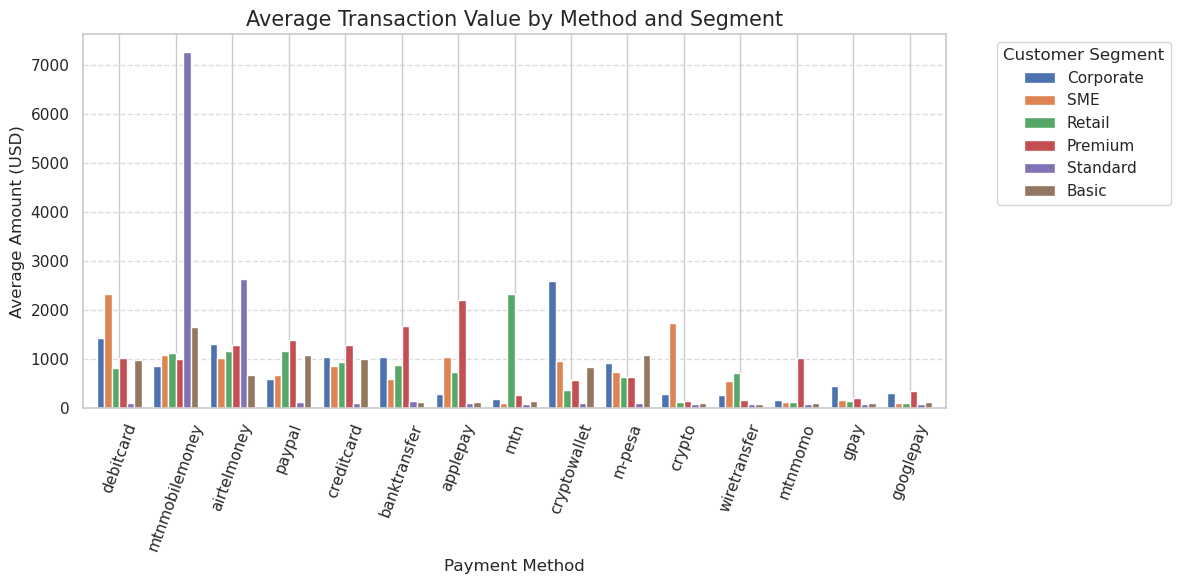

In [54]:
import matplotlib.pyplot as plt

# 1. Set the payment method as the index so it becomes the X-axis labels
df_plot = df_avg_transaction_value.set_index('clean_payment_method')

# 2. Drop the 'method_overall_avg' so it doesn't skew the bar heights
df_plot = df_plot.drop(columns=['method_overall_avg'])

# 3. Plot
df_plot.plot(kind='bar', figsize=(12, 6), width=0.8)

plt.title('Average Transaction Value by Method and Segment', fontsize=15)
plt.ylabel('Average Amount (USD)')
plt.xlabel('Payment Method')
plt.xticks(rotation=70) # Keeps names horizontal for readability
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### What is the fraud rate by payment method, device type, and country?


In [55]:
df_fraud_rate=pd.read_sql("""
SELECT SUM(CASE WHEN is_fraud=1 THEN 1
        ELSE 0 END)*1.0/ COUNT(*) AS fraud_rate,
        payment_method,
        device_type,
        country
                    FROM transactions
                    GROUP BY payment_method, device_type, country
                    ORDER BY fraud_rate DESC
""",conn)

df_fraud_rate.head(10)

,fraud_rate,payment_method,device_type,country
0,0.333333,Airtelmoney,Desktop,Germany
1,0.333333,Applepay,Tablet,France
2,0.333333,Creditcard,Tablet,Germany
3,0.333333,Cryptocurrency,Mobile,Germany
4,0.300000,Crypto,Mobile,Tanzania
5,0.250000,Creditcard,Tablet,Tanzania
6,0.250000,Crypto,Desktop,Egypt
7,0.250000,Cryptocurrency,Desktop,Uganda
8,0.250000,Googlepay,Desktop,United Kingdom
9,0.250000,Googlepay,Tablet,Tanzania


visualization for fraud rate by payment_method,country and device_type

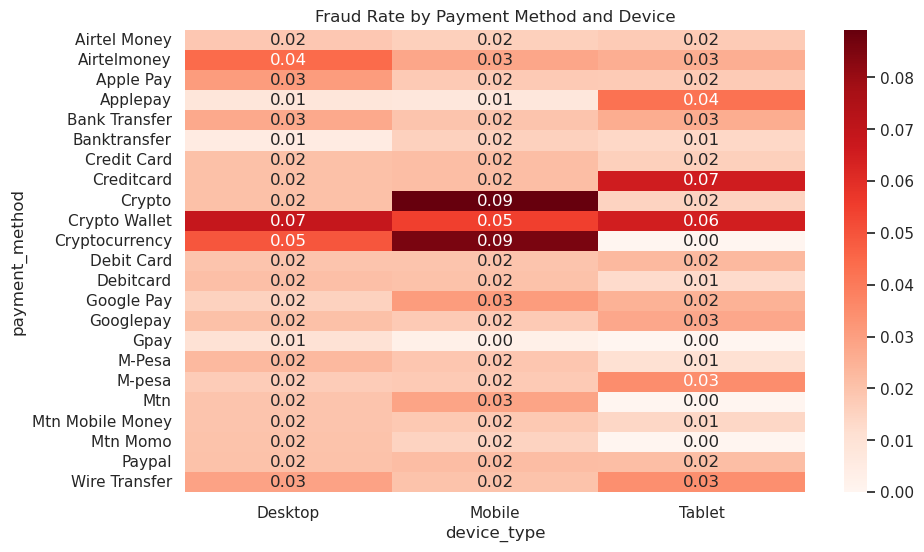

In [56]:

# 1. Prepare the data (Pivot it)
# We'll look at Payment Method vs Device Type
pivot_df = df_fraud_rate.pivot_table(index='payment_method', 
                                     columns='device_type', 
                                     values='fraud_rate')

# 2. Plot
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap='Reds', fmt='.2f')
plt.title('Fraud Rate by Payment Method and Device')
plt.show()

### Is there a statistically significant pattern between session duration and fraud likelihood?


In [57]:
df_session_duration = pd.read_sql("""
    SELECT 
        AVG(CAST(is_fraud AS FLOAT)) AS fraud_rate,
        COUNT(*) AS total_transactions,
        (session_duration_sec / 60) * 60 AS session_bucket_sec
    FROM transactions
    GROUP BY session_bucket_sec
    ORDER BY session_bucket_sec DESC
""", conn)
df_session_duration.head(10)

,fraud_rate,total_transactions,session_bucket_sec
0,0.0,1,21023.6
1,0.0,1,20466.3
2,0.0,1,18406.0
3,0.0,1,17924.9
4,0.0,1,17637.8
5,0.0,1,17284.5
6,0.0,1,17159.3
7,1.0,1,16989.6
8,0.0,1,15728.8
9,0.0,1,15538.8


visualisation ratte by fraud

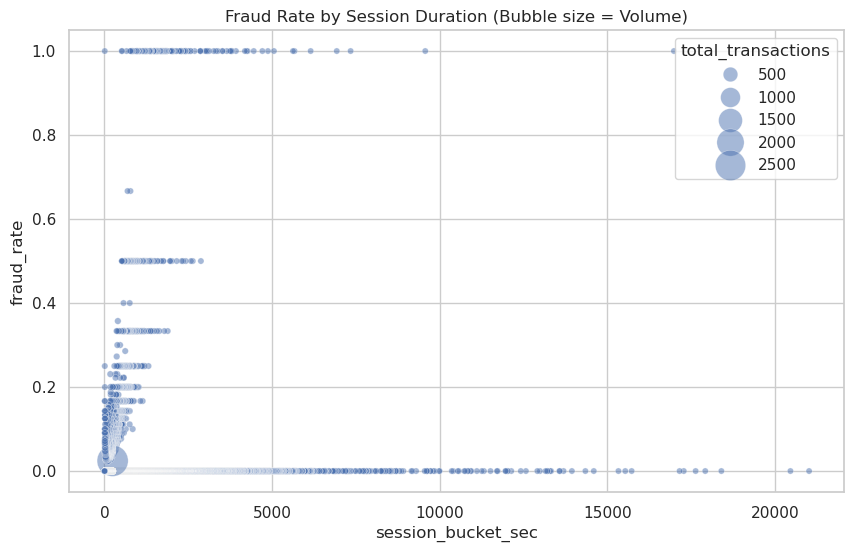

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_session_duration, 
                x='session_bucket_sec', 
                y='fraud_rate', 
                size='total_transactions', 
                sizes=(20, 500), 
                alpha=0.5)
plt.title('Fraud Rate by Session Duration (Bubble size = Volume)')
plt.show()

/tmp/ipykernel_66337/993506989.py:24: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, top10['fraud_rate'].max() * 1.2)


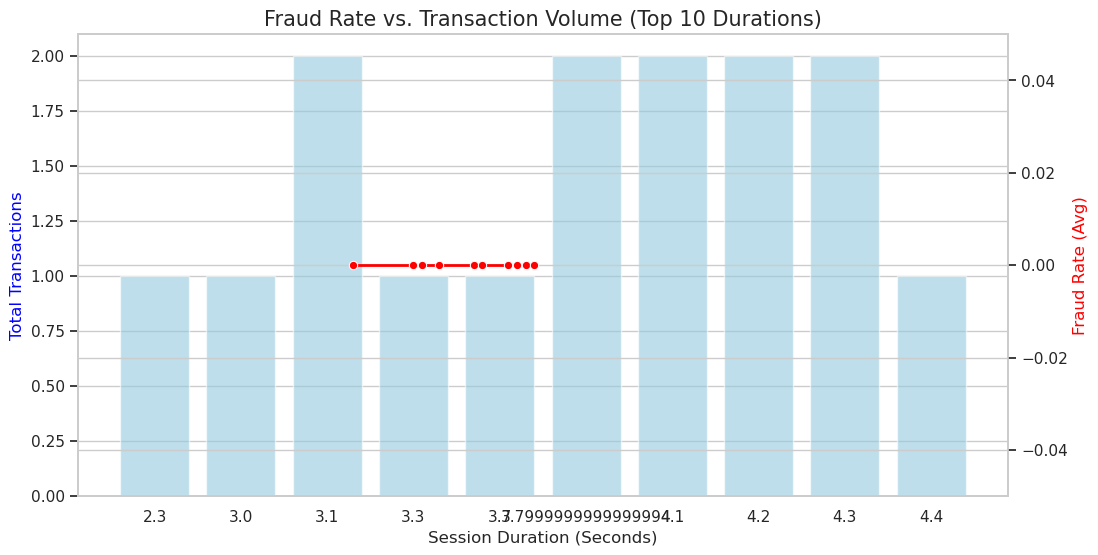

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Grab the data (sorting by duration so the line flows left-to-right)
top10 = df_session_duration.sort_values('session_bucket_sec', ascending=True).head(10)

# 2. Primary Axis: Total Transactions
sns.barplot(data=top10, x='session_bucket_sec', y='total_transactions', 
            color='skyblue', alpha=0.6, ax=ax1)
ax1.set_ylabel('Total Transactions', fontsize=12, color='blue')
ax1.set_xlabel('Session Duration (Seconds)', fontsize=12)

# 3. Secondary Axis: Fraud Rate
ax2 = ax1.twinx()
# x and y parameters
sns.lineplot(data=top10, x='session_bucket_sec', y='fraud_rate', 
             color='red', marker='o', linewidth=2, ax=ax2, sort=False)
ax2.set_ylabel('Fraud Rate (Avg)', fontsize=12, color='red')

# Ensure the y-axis for fraud makes sense (0 to 1 or 0 to max rate)
ax2.set_ylim(0, top10['fraud_rate'].max() * 1.2)

plt.title('Fraud Rate vs. Transaction Volume (Top 10 Durations)', fontsize=15)
plt.show()

Which merchant IDs have the highest chargeback rates, and what is the associated revenue impact?

In [61]:
df_merchant=pd.read_sql("""
SELECT merchant_name,
        COUNT(*) AS total_transactions,
        SUM(chargeback_flag) AS total_chargebacks,
        ROUND(AVG(CAST(chargeback_flag AS FLOAT)) * 100, 2) AS chargeback_rate_pct,
        ROUND(SUM(net_revenue_usd), 2) AS total_revenue_usd,
        ROUND(SUM(CASE WHEN chargeback_flag = 1 THEN net_revenue_usd ELSE 0 END), 2) AS revenue_at_risk_usd
                        FROM transactions
                        GROUP BY merchant_id, merchant_name
                        ORDER BY chargeback_rate_pct DESC
""",conn)
df_merchant.head(10)

,merchant_name,total_transactions,total_chargebacks,chargeback_rate_pct,total_revenue_usd,revenue_at_risk_usd
0,Cobb-Trujillo,367,10,2.72,41268.35,1240.42
1,"Clay, Moore and Alvarez",317,8,2.52,38134.39,1203.45
2,"Kirk, Huffman and Eaton",331,8,2.42,46126.02,901.42
3,"Anderson, Thompson and Pena",310,7,2.26,137048.98,881.82
4,"Davis, Fernandez and Rivera",314,7,2.23,428216.37,511.10
5,"Austin, Williams and Walton",316,7,2.22,644874.75,471.27
6,Butler-Gonzalez,329,7,2.13,36346.38,576.20
7,Arnold-Holder,332,7,2.11,49858.23,2673.77
8,Nichols LLC,338,7,2.07,38292.37,542.72
9,Stuart Group,351,7,1.99,541716.53,677.78


visualization of the merchants by chargeback rates

/tmp/ipykernel_66337/1568963240.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


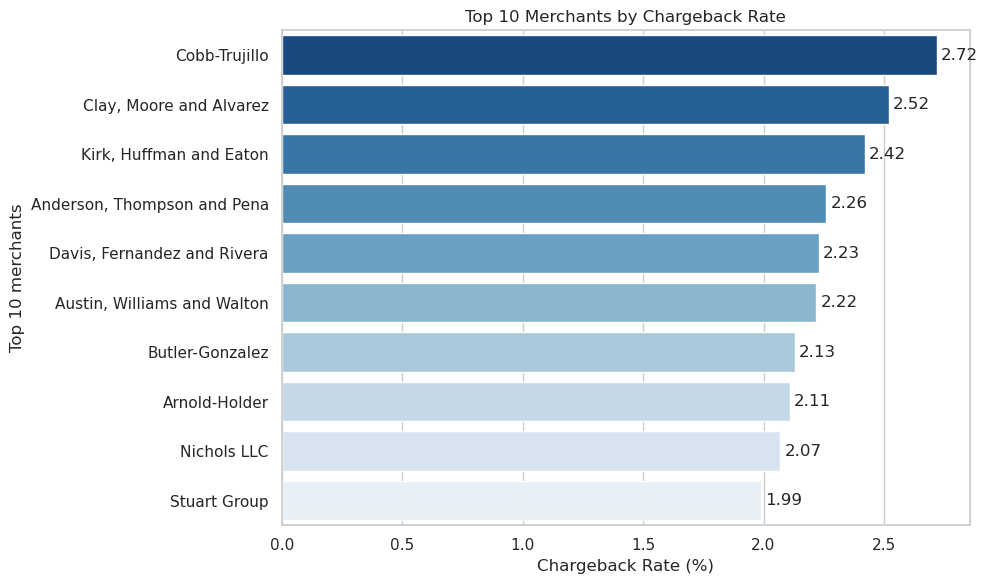

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# take only top 10
top10 = df_merchant.nlargest(10, 'chargeback_rate_pct')

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top10,
    x='chargeback_rate_pct',
    y='merchant_name',
    palette='Blues_r'
    
)

ax.set_xlabel('Chargeback Rate (%)')
ax.set_ylabel('Top 10 merchants')
ax.set_title('Top 10 Merchants by Chargeback Rate')
for container in ax.containers:
    ax.bar_label(container, padding=3)

#sns.despine()
plt.tight_layout()
plt.show()